In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/220138_linear.ipynb/Housing.zip')
print(df.shape)
df.head()

(545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [10]:
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Shape: (545, 13)

Column Names:
 ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Data Types:
 price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

Missing Values:
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Basic Statistics:


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")

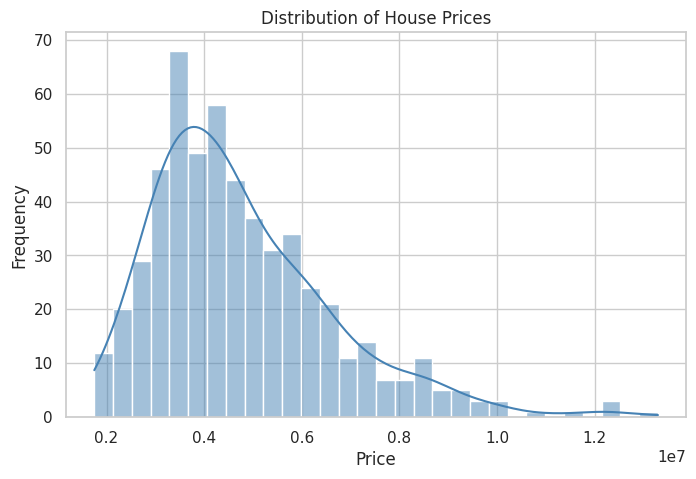

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

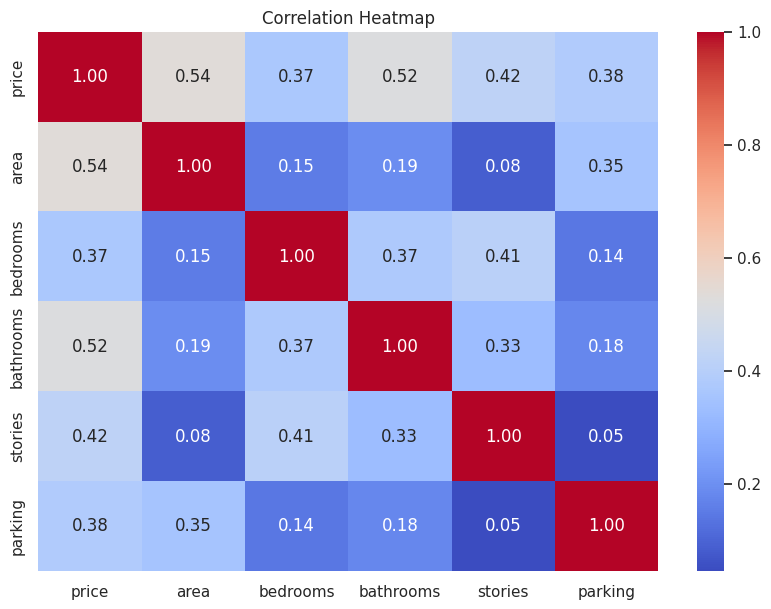

In [16]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

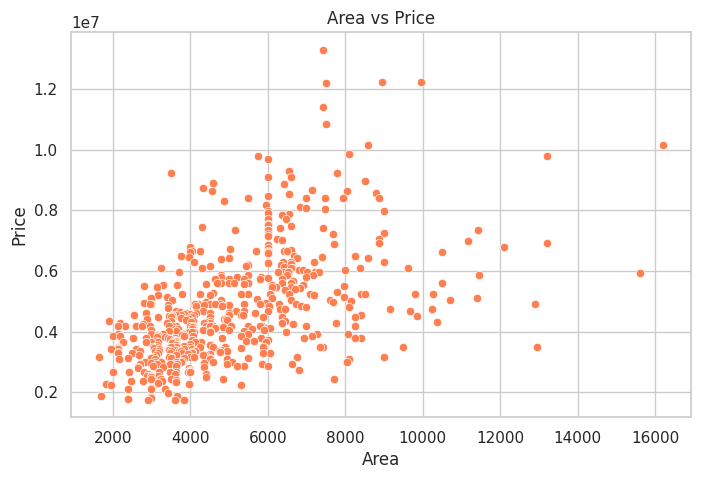

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='area', y='price', data=df, color='coral')
plt.title('Area vs Price')
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()

/tmp/ipykernel_9087/2513960930.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='bedrooms', y='price', data=df, palette='Set2')


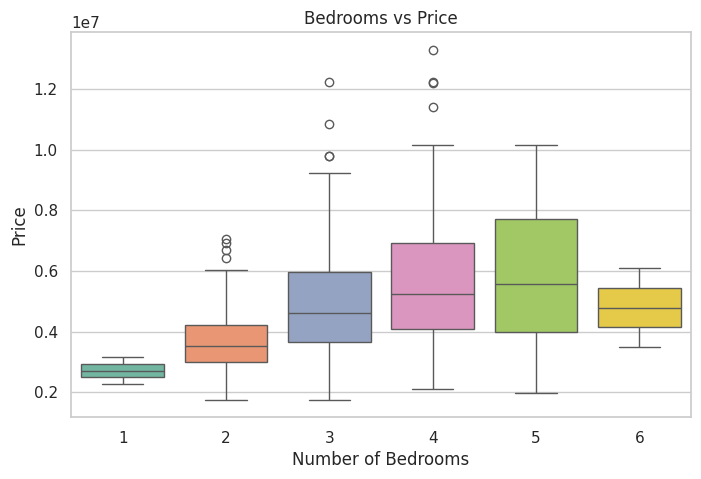

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x='bedrooms', y='price', data=df, palette='Set2')
plt.title('Bedrooms vs Price')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')
plt.show()

/tmp/ipykernel_9087/1720168248.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='pastel')
/tmp/ipykernel_9087/1720168248.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='pastel')
/tmp/ipykernel_9087/1720168248.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='pastel')
/tmp/ipykernel_9087/1720168248.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `

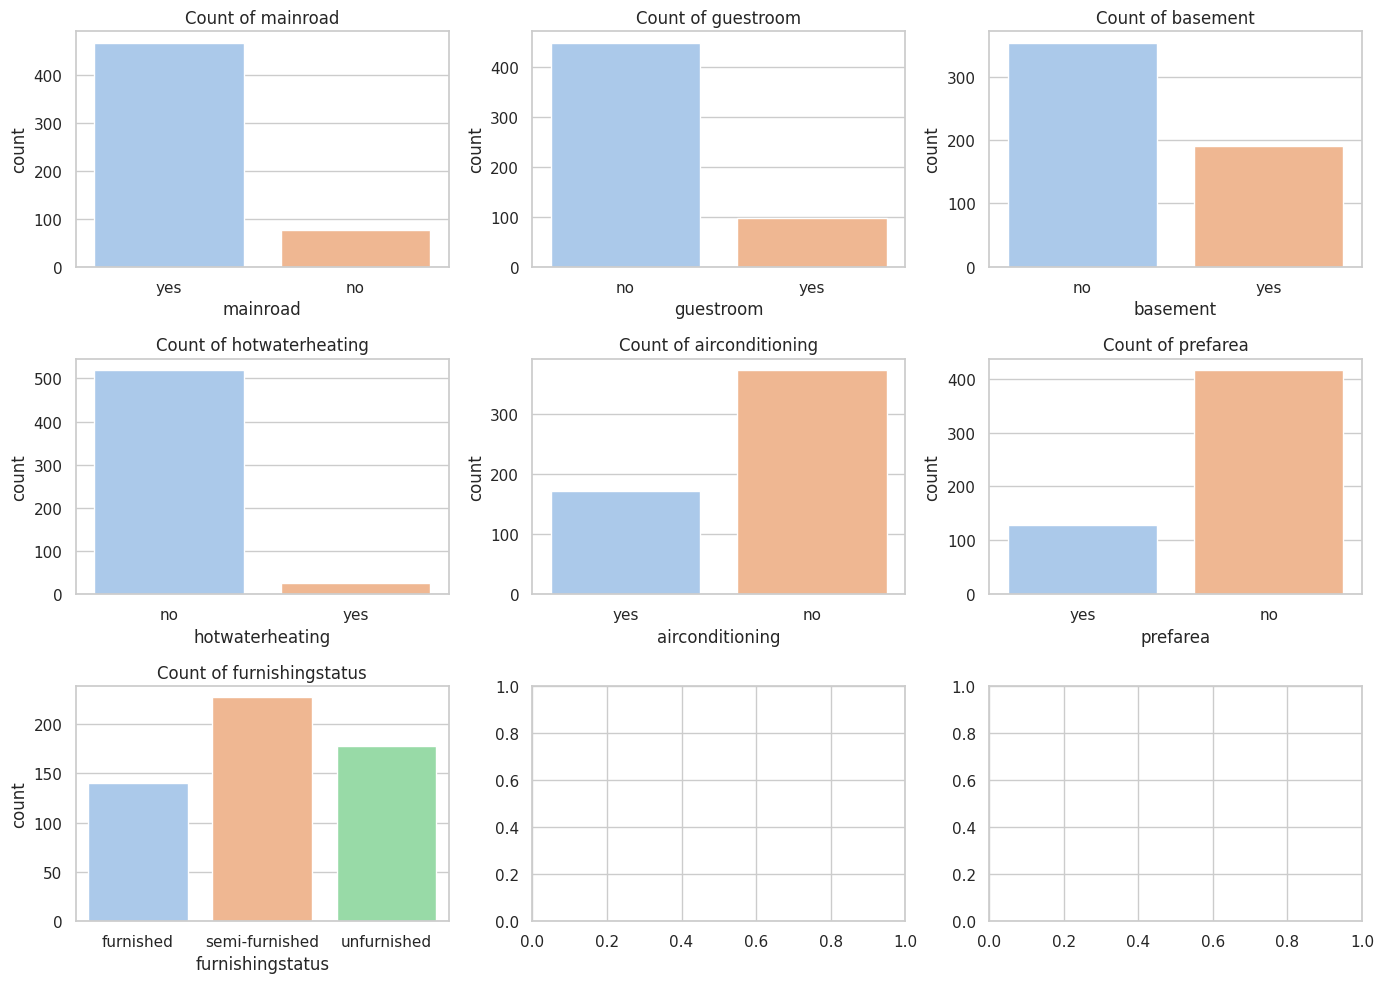

In [19]:
cat_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
            'airconditioning', 'prefarea', 'furnishingstatus']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=df, ax=axes[i], palette='pastel')
    axes[i].set_title(f'Count of {col}')

plt.tight_layout()
plt.show()

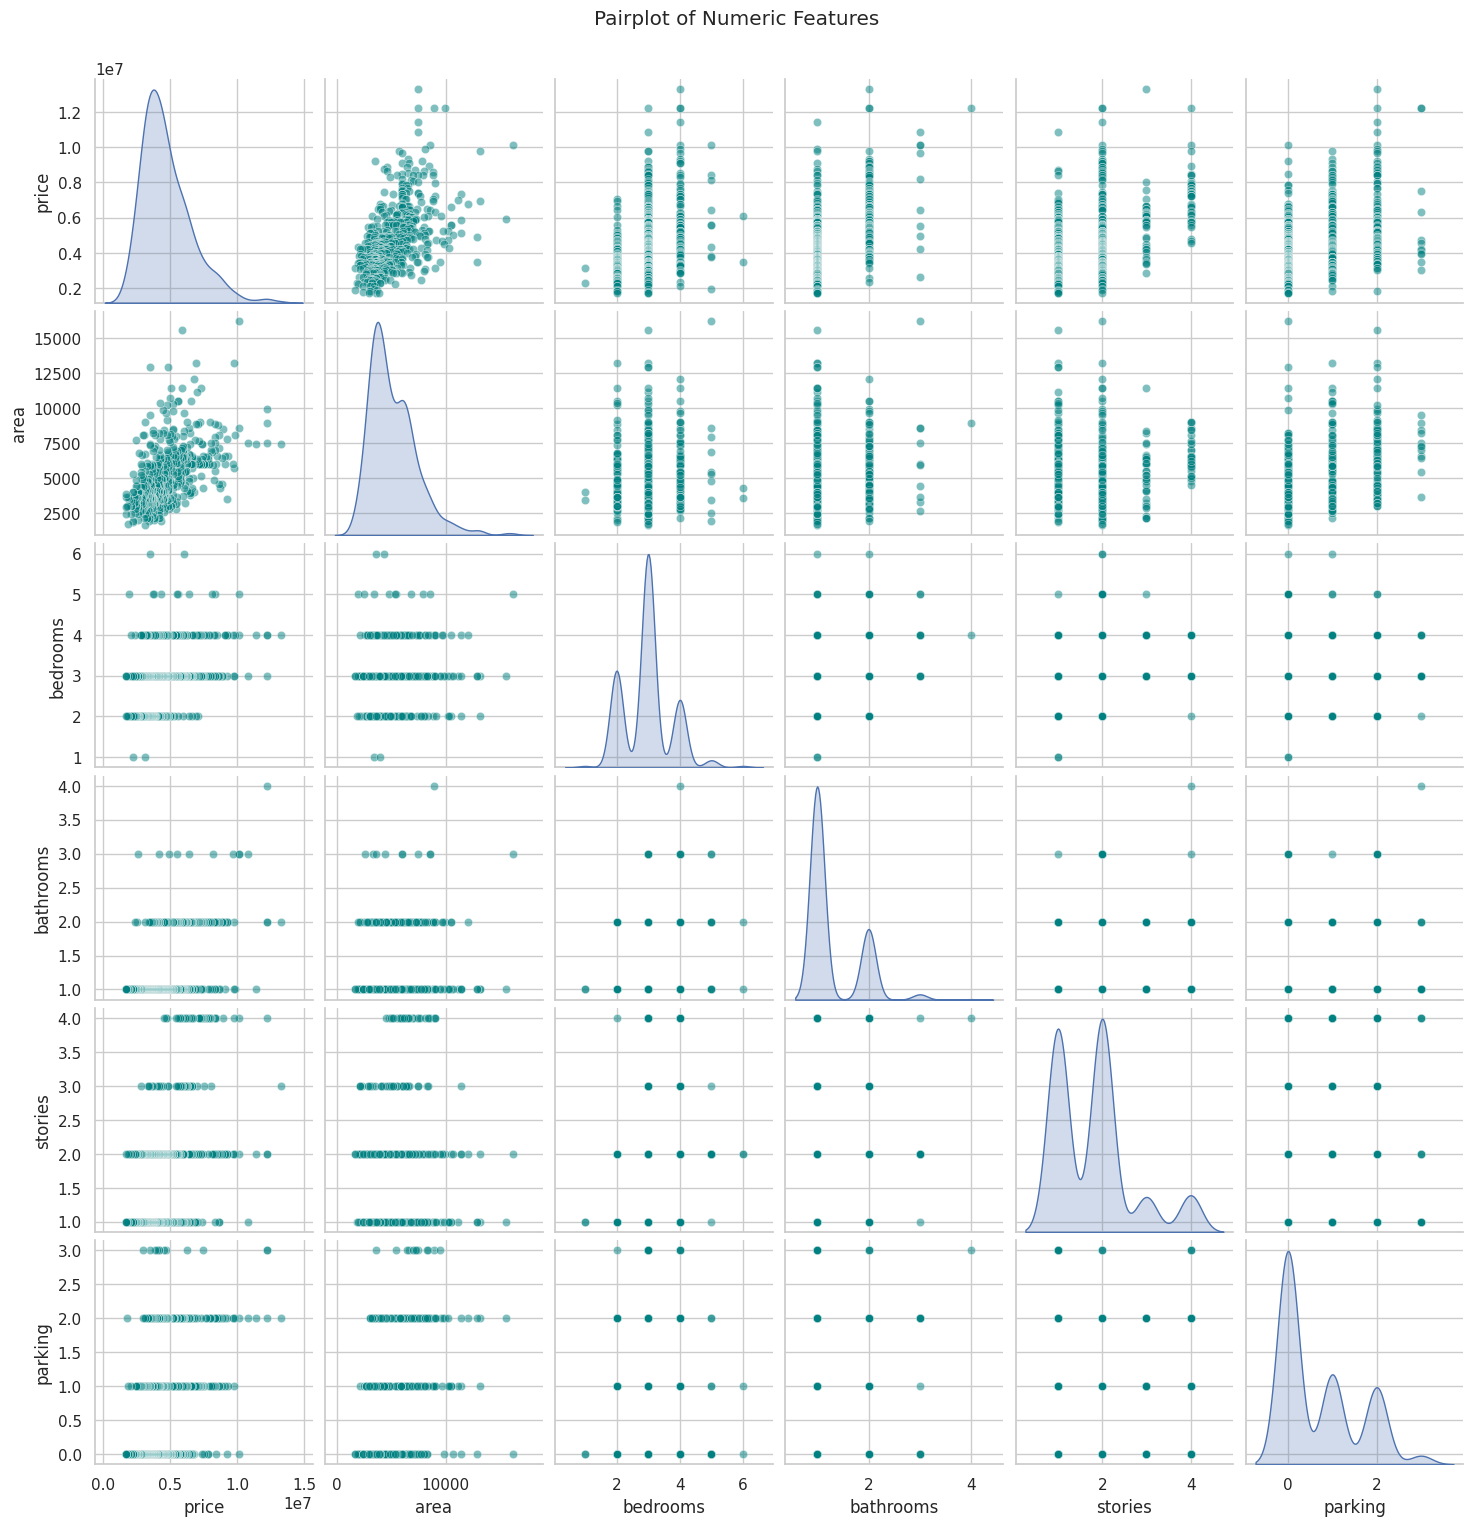

In [20]:
num_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
sns.pairplot(df[num_cols], diag_kind='kde', plot_kws={'alpha':0.5, 'color':'teal'})
plt.suptitle('Pairplot of Numeric Features', y=1.02)
plt.show()

In [21]:
# Check missing values
print("Missing Values Before:\n", df.isnull().sum())

# Fill missing numeric values with median (if any)
df.fillna(df.median(numeric_only=True), inplace=True)

print("\nMissing Values After:\n", df.isnull().sum())

Missing Values Before:
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Missing Values After:
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [22]:
# Convert yes/no columns to 1/0
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
               'airconditioning', 'prefarea']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# Encode furnishingstatus (3 categories)
df['furnishingstatus'] = df['furnishingstatus'].map({
    'furnished': 2,
    'semi-furnished': 1,
    'unfurnished': 0
})

print("Encoding done ✅")
df.head()

Encoding done ✅


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2


In [23]:
# Separate features (X) and target (y)
X = df.drop(columns=['price'])
y = df['price']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures used:\n", X.columns.tolist())

Features shape: (545, 12)
Target shape: (545,)

Features used:
 ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling done ✅")
print("Sample scaled values:\n", X_scaled[:3])

Scaling done ✅
Sample scaled values:
 [[ 1.04672629  1.40341936  1.42181174  1.37821692  0.40562287 -0.46531479
  -0.73453933 -0.2192645   1.4726183   1.51769249  1.80494113  1.40628573]
 [ 1.75700953  1.40341936  5.40580863  2.53202371  0.40562287 -0.46531479
  -0.73453933 -0.2192645   1.4726183   2.67940935 -0.55403469  1.40628573]
 [ 2.21823241  0.04727831  1.42181174  0.22441013  0.40562287 -0.46531479
   1.3613975  -0.2192645  -0.67906259  1.51769249  1.80494113  0.09166185]]


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size :", X_test.shape)

Training set size: (436, 12)
Testing set size : (109, 12)


In [26]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully ✅")

Model trained successfully ✅


In [27]:
# Predict on test set
y_pred = model.predict(X_test)

print("Predictions done ✅")
print("\nFirst 5 Predicted Values:", y_pred[:5])
print("First 5 Actual Values:   ", y_test.values[:5])

Predictions done ✅

First 5 Predicted Values: [5203691.70963177 7257004.02115475 3062828.59668172 4559591.65374424
 3332932.30559783]
First 5 Actual Values:    [4060000 6650000 3710000 6440000 2800000]


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("📊 Model Performance:")
print(f"   MAE  : {mae:,.2f}")
print(f"   MSE  : {mse:,.2f}")
print(f"   RMSE : {rmse:,.2f}")
print(f"   R²   : {r2:.4f}")

📊 Model Performance:
   MAE  : 979,679.69
   MSE  : 1,771,751,116,594.04
   RMSE : 1,331,071.42
   R²   : 0.6495


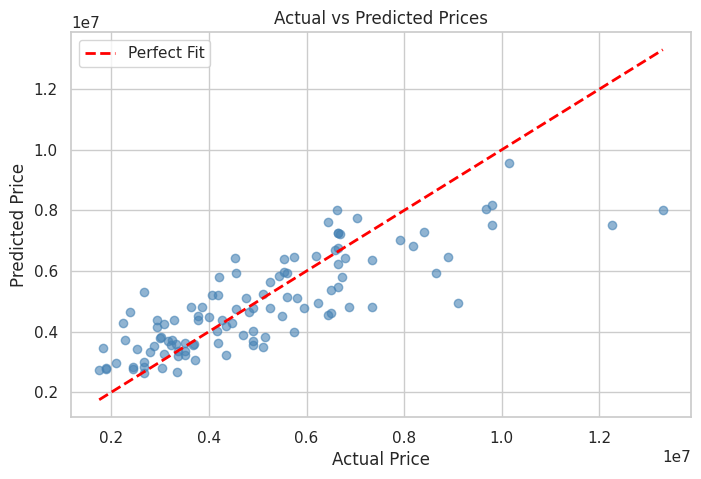

In [29]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, color='steelblue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, linestyle='--', label='Perfect Fit')
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.show()

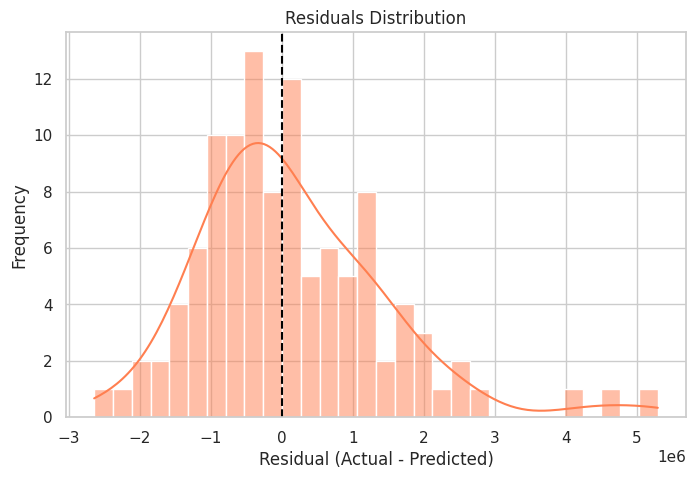

In [30]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=30, kde=True, color='coral')
plt.title('Residuals Distribution')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.axvline(0, color='black', linestyle='--')
plt.show()

In [31]:
sample = pd.DataFrame({
    'Actual Price'   : y_test.values[:10],
    'Predicted Price': y_pred[:10].round(2),
    'Difference'     : (y_test.values[:10] - y_pred[:10]).round(2)
})

print("📋 Sample Predictions:")
print(sample.to_string(index=False))

📋 Sample Predictions:
 Actual Price  Predicted Price  Difference
      4060000       5203691.71 -1143691.71
      6650000       7257004.02  -607004.02
      3710000       3062828.60   647171.40
      6440000       4559591.65  1880408.35
      2800000       3332932.31  -532932.31
      4900000       3563080.68  1336919.32
      5250000       5645466.31  -395466.31
      4543000       6413979.67 -1870979.67
      2450000       2755831.55  -305831.55
      3353000       2668938.66   684061.34


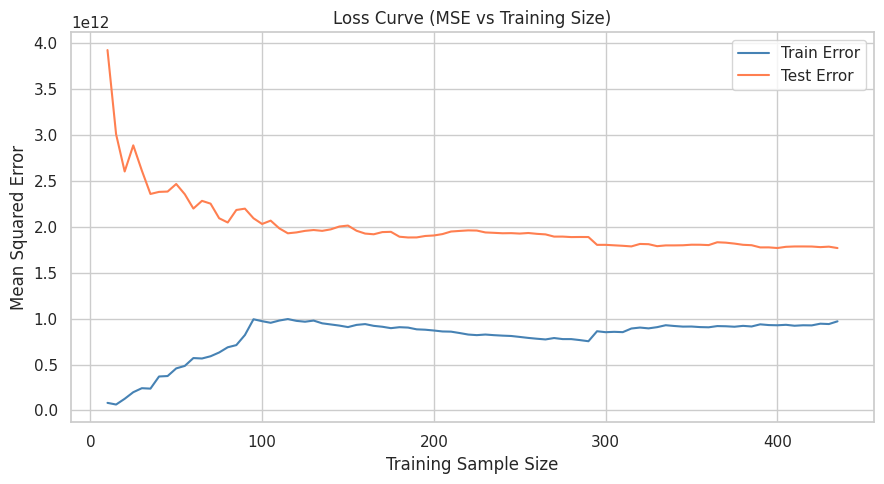

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

train_errors = []
test_errors  = []
sizes = range(10, len(X_train), 5)

for s in sizes:
    model_lc = LinearRegression()
    model_lc.fit(X_train[:s], y_train[:s])

    train_pred = model_lc.predict(X_train[:s])
    test_pred  = model_lc.predict(X_test)

    train_errors.append(mean_squared_error(y_train[:s], train_pred))
    test_errors.append(mean_squared_error(y_test, test_pred))

plt.figure(figsize=(9,5))
plt.plot(sizes, train_errors, label='Train Error', color='steelblue')
plt.plot(sizes, test_errors,  label='Test Error',  color='coral')
plt.title('Loss Curve (MSE vs Training Size)')
plt.xlabel('Training Sample Size')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_9087/104166503.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='coolwarm')


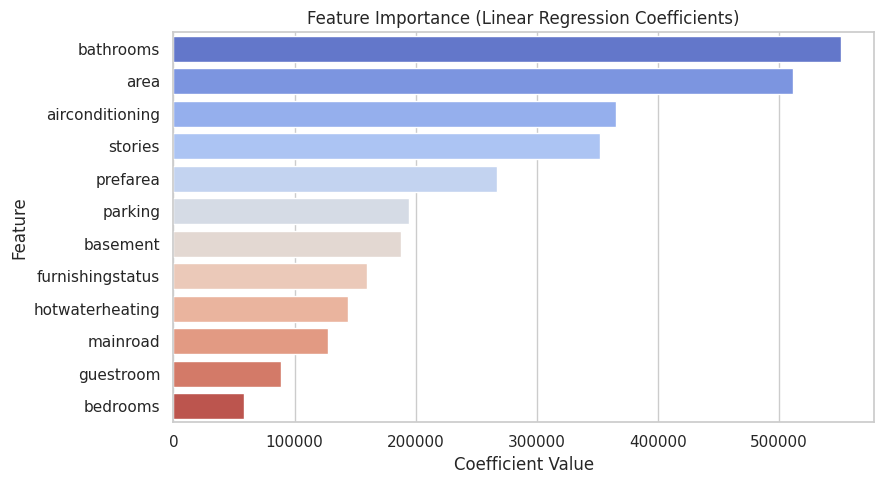

         Feature   Coefficient
       bathrooms 550762.108735
            area 511355.314864
 airconditioning 365086.933939
         stories 352072.086344
        prefarea 267023.364350
         parking 194330.065331
        basement 187581.884388
furnishingstatus 160043.584438
 hotwaterheating 143909.241493
        mainroad 127770.253636
       guestroom  89178.007942
        bedrooms  57939.764185


In [33]:
feature_names = df.drop(columns=['price']).columns

coef_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(9,5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='coolwarm')
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))

In [34]:
print("=" * 40)
print("       FINAL MODEL SUMMARY")
print("=" * 40)
print(f"  Model      : Linear Regression")
print(f"  Dataset    : Housing Prices")
print(f"  Features   : {X_train.shape[1]}")
print(f"  Train Size : {X_train.shape[0]} samples")
print(f"  Test Size  : {X_test.shape[0]} samples")
print("-" * 40)
print(f"  MAE        : {mae:,.2f}")
print(f"  MSE        : {mse:,.2f}")
print(f"  RMSE       : {rmse:,.2f}")
print(f"  R² Score   : {r2:.4f}")
print("=" * 40)

       FINAL MODEL SUMMARY
  Model      : Linear Regression
  Dataset    : Housing Prices
  Features   : 12
  Train Size : 436 samples
  Test Size  : 109 samples
----------------------------------------
  MAE        : 979,679.69
  MSE        : 1,771,751,116,594.04
  RMSE       : 1,331,071.42
  R² Score   : 0.6495
